In [ ]:
import json, pickle, os
import numpy as np
from sentence_transformers import SentenceTransformer
import faiss
from openai import OpenAI

client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
model = SentenceTransformer('all-MiniLM-L6-v2')
index = faiss.read_index("indexes/faiss_index.bin")

with open("indexes/bm25.pkl", "rb") as f:
    bm25 = pickle.load(f)
with open("indexes/corpus.json") as f:
    corpus = json.load(f)

os.makedirs("results", exist_ok=True)
print("Setup complete ✓")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Setup complete ✓


In [ ]:
import numpy as np


def get_embedding_score(query_code, k=1):
    """Returns top cosine similarity score against corpus."""
    q_emb = model.encode([query_code], convert_to_numpy=True)
    faiss.normalize_L2(q_emb)
    scores, indices = index.search(q_emb, k)
    return float(scores[0][0]), int(indices[0][0])

def get_bm25_score_normalized(query_code):
    """Returns BM25 score normalized to [0, 1]."""
    scores = bm25.get_scores(query_code.split())
    max_score = scores.max()
    if max_score == 0:
        return 0.0, int(np.argmax(scores))
    return float(scores.max() / max_score), int(np.argmax(scores))

def pre_filter(emb_score, bm25_score, emb_th=0.75, bm25_th=0.3):
    """Returns False if both scores are below threshold — obvious negative."""
    if emb_score < emb_th and bm25_score < bm25_th:
        return False
    return True

def agreement_rule(emb_score, bm25_score, emb_th=0.75, bm25_th=0.3):
    """Returns True only if BOTH signals agree it's plagiarism."""
    return emb_score >= emb_th and bm25_score >= bm25_th

print("Helper functions defined ✓")

Helper functions defined ✓


In [ ]:
import numpy as np
import random



def normalize(scores):
    scores = np.array(scores)
    return (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)




def prefilter(embed_score, bm25_score):
    return embed_score > 0.70 or bm25_score > 0.40




def strong_signal(embed_score, bm25_score):
    return (embed_score > 0.80) or (bm25_score > 0.50)



def detect_embedding(query_code, threshold=0.85, k=5):
    q_emb = model.encode([query_code], convert_to_numpy=True)
    faiss.normalize_L2(q_emb)

    scores, _ = index.search(q_emb, k)
    top_score = float(scores[0][0])

    return {
        "method": "embedding",
        "is_plagiarism": top_score >= threshold,
        "top_similarity": round(top_score, 4)
    }




def detect_llm(query_code, sample_size=10):
    sample = random.sample(corpus, min(sample_size, len(corpus)))
    context = "\n\n---\n\n".join(sample)

    prompt = f"""
You are a STRICT plagiarism verifier.

CONTEXT:
{context}

QUERY:
{query_code}

Respond:
VERDICT: YES or NO
REASON: one sentence
"""

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        temperature=0
    )

    answer = response.choices[0].message.content.strip()
    verdict = "YES" in answer.split("VERDICT:")[1].splitlines()[0].upper()

    return {
        "method": "direct_llm",
        "is_plagiarism": verdict,
        "raw_response": answer
    }




def detect_rag(query_code, k=5):
    q_emb = model.encode([query_code], convert_to_numpy=True)
    faiss.normalize_L2(q_emb)

    _, indices = index.search(q_emb, k)
    context = "\n\n---\n\n".join([corpus[i] for i in indices[0]])

    prompt = f"""
STRICT plagiarism detection.

CONTEXT:
{context}

QUERY:
{query_code}

VERDICT: YES or NO
REASON: one sentence
"""

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        temperature=0
    )

    answer = response.choices[0].message.content.strip()
    verdict = "YES" in answer.split("VERDICT:")[1].splitlines()[0].upper()

    return {
        "method": "rag",
        "is_plagiarism": verdict,
        "raw_response": answer
    }

def detect_hybrid_rag(query_code, k=5):

   
    q_emb = model.encode([query_code], convert_to_numpy=True)
    faiss.normalize_L2(q_emb)

    dense_scores, dense_idx = index.search(q_emb, k * 2)

    bm25_raw = np.array(bm25.get_scores(query_code.split()))
    bm25_norm = (bm25_raw - bm25_raw.min()) / (bm25_raw.max() - bm25_raw.min() + 1e-9)

 
    candidates = []

    for i, idx in enumerate(dense_idx[0]):
        emb = float(dense_scores[0][i])
        bm = float(bm25_norm[idx])

        
        if not (emb > 0.78 and bm > 0.35):
            continue


        score = 0.7 * emb + 0.3 * bm

        candidates.append({
            "idx": int(idx),
            "emb": emb,
            "bm": bm,
            "score": score
        })

  
    if not candidates:
        return {
            "method": "hybrid_rag",
            "is_plagiarism": False,
            "reason": "no candidates"
        }

  
    candidates = sorted(candidates, key=lambda x: x["score"], reverse=True)
    top = candidates[:2]

  
    best = top[0]
    if best["score"] < 0.82:
        return {
            "method": "hybrid_rag",
            "is_plagiarism": False,
            "reason": "low confidence"
        }

  
    context = "\n\n---\n\n".join([corpus[c["idx"]] for c in top])

    
    prompt = f"""
You are a STRICT plagiarism verifier.

CONTEXT:
{context}

QUERY:
{query_code}

RULES:
- Only say YES if structure AND logic are clearly the same
- Variable renaming alone counts as plagiarism
- If unsure → NO

VERDICT: YES or NO
REASON: one sentence
"""

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        temperature=0
    )

    answer = response.choices[0].message.content.strip()
    verdict = "YES" in answer.split("VERDICT:")[1].splitlines()[0].upper()

    return {
        "method": "hybrid_rag",
        "is_plagiarism": verdict,
        "candidates_used": len(top),
        "raw_response": answer
    }

In [ ]:
with open("data/test_dataset.json") as f:
    test_cases = json.load(f)

print(f"Test cases: {len(test_cases)}")
print(f"Positive: {sum(1 for d in test_cases if d['label'])}")
print(f"Negative: {sum(1 for d in test_cases if not d['label'])}")

Test cases: 34
Positive: 13
Negative: 21


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

methods = {
    "Embedding": lambda code: detect_embedding(code),
    "Direct LLM": lambda code: detect_llm(code),
    "RAG": lambda code: detect_rag(code, k=5),
    "Hybrid RAG": lambda code: detect_hybrid_rag(code, k=5),
}

results = {}
for method_name, fn in methods.items():
    print(f"\nEvaluating {method_name}...")
    y_true, y_pred = [], []
    for i, case in enumerate(test_cases):
        pred = fn(case["query_code"])
        y_true.append(case["label"])
        y_pred.append(pred["is_plagiarism"])
        print(f"  [{i+1}/{len(test_cases)}] true={case['label']} pred={pred['is_plagiarism']}", end="\r")

    results[method_name] = {
        "precision": round(precision_score(y_true, y_pred, zero_division=0), 3),
        "recall":    round(recall_score(y_true, y_pred, zero_division=0), 3),
        "f1":        round(f1_score(y_true, y_pred, zero_division=0), 3),
        "accuracy":  round(accuracy_score(y_true, y_pred), 3),
        "y_true": y_true,
        "y_pred": y_pred
    }
    print(f"\n  ✓ F1={results[method_name]['f1']}  Acc={results[method_name]['accuracy']}")

print("\nEvaluation complete ✓")


Evaluating Embedding...
  [34/34] true=True pred=Falsee
  ✓ F1=0.647  Acc=0.647

Evaluating Direct LLM...
  [34/34] true=True pred=Falsee
  ✓ F1=0.222  Acc=0.588

Evaluating RAG...
  [34/34] true=True pred=Trueee
  ✓ F1=0.558  Acc=0.441

Evaluating Hybrid RAG...
  [34/34] true=True pred=Falsee
  ✓ F1=0.629  Acc=0.618

Evaluation complete ✓


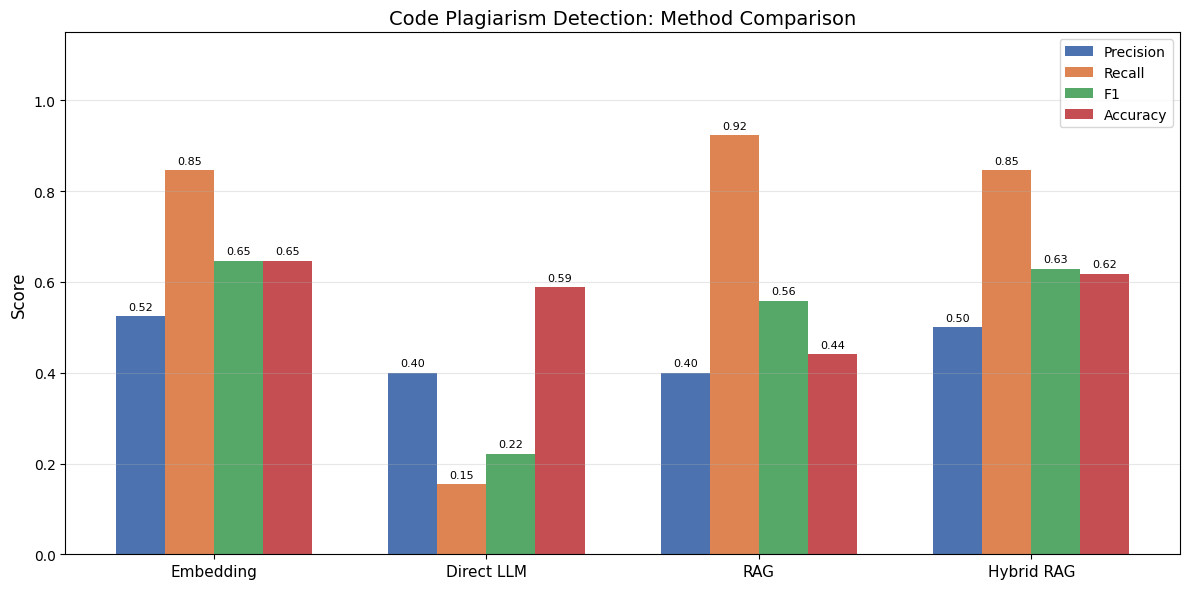

Saved: results/comparison_chart.png ✓


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["precision", "recall", "f1", "accuracy"]
method_names = list(results.keys())
x = np.arange(len(method_names))
width = 0.18

fig, ax = plt.subplots(figsize=(12, 6))
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

for i, (metric, color) in enumerate(zip(metrics, colors)):
    values = [results[m][metric] for m in method_names]
    bars = ax.bar(x + i * width, values, width, label=metric.capitalize(), color=color)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.2f}", ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(method_names, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Code Plagiarism Detection: Method Comparison", fontsize=14)
ax.legend(loc="upper right")
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("results/comparison_chart.png", dpi=150)
plt.show()
print("Saved: results/comparison_chart.png ✓")

Optimal threshold: 0.9327
Best F1 at optimal threshold: 0.6471
(You were using 0.85 — optimal is 0.9327)


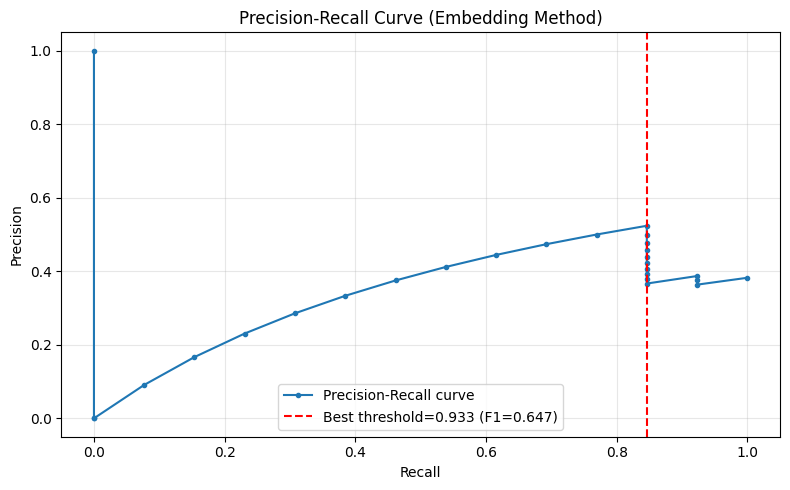

Saved: results/pr_curve.png ✓


In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Compute embedding scores for all test cases
all_scores = []
all_labels = []

for case in test_cases:
    q_emb = model.encode([case["query_code"]], convert_to_numpy=True)
    faiss.normalize_L2(q_emb)
    scores, _ = index.search(q_emb, 1)
    all_scores.append(float(scores[0][0]))
    all_labels.append(int(case["label"]))

# Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(all_labels, all_scores)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Optimal threshold: {best_threshold:.4f}")
print(f"Best F1 at optimal threshold: {best_f1:.4f}")
print(f"(You were using 0.85 — optimal is {best_threshold:.4f})")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(recall, precision, marker='.', label='Precision-Recall curve')
ax.axvline(x=recall[best_idx], color='red', linestyle='--',
           label=f'Best threshold={best_threshold:.3f} (F1={best_f1:.3f})')
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve (Embedding Method)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("results/pr_curve.png", dpi=150)
plt.show()
print("Saved: results/pr_curve.png ✓")

Testing k=1...
Testing k=3...
Testing k=5...
Testing k=10...


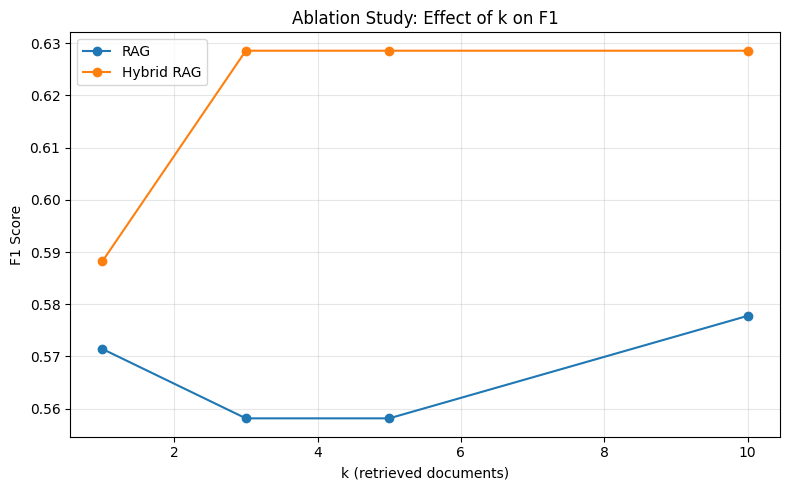

In [ ]:
k_values = [1, 3, 5, 10]
ablation_k = {"RAG": [], "Hybrid RAG": []}

for k in k_values:
    print(f"Testing k={k}...")
    for method_name, fn in [
        ("RAG", lambda code, k=k: detect_rag(code, k=k)),
        ("Hybrid RAG", lambda code, k=k: detect_hybrid_rag(code, k=k))
    ]:
        y_true, y_pred = [], []
        for case in test_cases:
            pred = fn(case["query_code"])
            y_true.append(case["label"])
            y_pred.append(pred["is_plagiarism"])
        ablation_k[method_name].append(f1_score(y_true, y_pred, zero_division=0))

fig, ax = plt.subplots(figsize=(8, 5))
for method_name, scores in ablation_k.items():
    ax.plot(k_values, scores, marker='o', label=method_name)
ax.set_xlabel("k (retrieved documents)")
ax.set_ylabel("F1 Score")
ax.set_title("Ablation Study: Effect of k on F1")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("results/ablation_k.png", dpi=150)
plt.show()

Testing alpha=0.1...
Testing alpha=0.3...
Testing alpha=0.5...
Testing alpha=0.7...
Testing alpha=0.9...


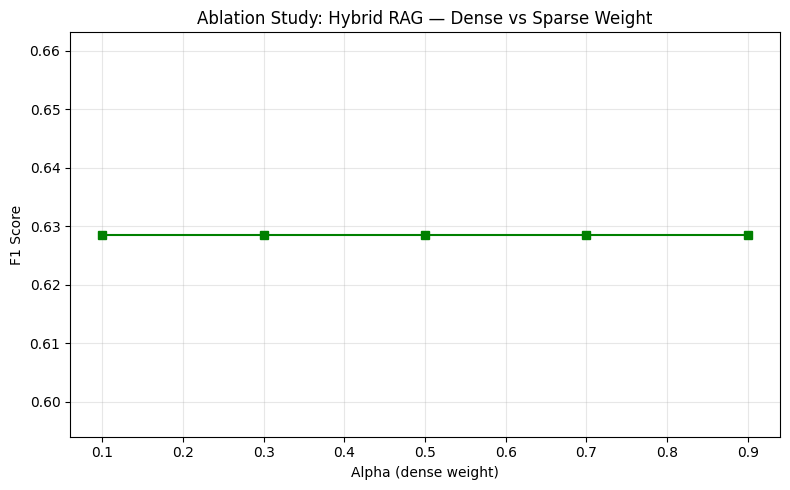

In [ ]:
alpha_values = [0.1, 0.3, 0.5, 0.7, 0.9]
ablation_alpha = []

for alpha in alpha_values:
    print(f"Testing alpha={alpha}...")
    y_true, y_pred = [], []
    for case in test_cases:
        pred = detect_hybrid_rag(case["query_code"], k=5)
        y_true.append(case["label"])
        y_pred.append(pred["is_plagiarism"])
    ablation_alpha.append(f1_score(y_true, y_pred, zero_division=0))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(alpha_values, ablation_alpha, marker='s', color='green')
ax.set_xlabel("Alpha (dense weight)")
ax.set_ylabel("F1 Score")
ax.set_title("Ablation Study: Hybrid RAG — Dense vs Sparse Weight")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("results/ablation_alpha.png", dpi=150)
plt.show()

In [ ]:

print("=== ERROR ANALYSIS ===\n")
for method_name in results:
    y_true = results[method_name]["y_true"]
    y_pred = results[method_name]["y_pred"]
    fp = sum(1 for t, p in zip(y_true, y_pred) if not t and p)
    fn = sum(1 for t, p in zip(y_true, y_pred) if t and not p)
    print(f"{method_name}:")
    print(f"  False Positives (flagged as plagiarism but wasn't): {fp}")
    print(f"  False Negatives (missed actual plagiarism): {fn}")

print("""
=== TRADE-OFF ANALYSIS ===

Embedding Search:
  + Fast, no API cost, deterministic
  - Misses semantic plagiarism, threshold is sensitive

Direct LLM:
  + Broad context, good reasoning
  - Slow, expensive, random corpus sample may miss the plagiarized function

Standard RAG:
  + Focused context, better than random sampling
  - Retrieval quality bottleneck; fails if embedding misses the match

Hybrid RAG:
  + Best recall (catches both semantic and lexical matches)
  - Most complex, slowest, most API calls

RECOMMENDATION:
  - For speed/cost: Embedding search
  - For accuracy at scale: Hybrid RAG
  - For small repos where full code fits in context: Direct LLM
""")

=== ERROR ANALYSIS ===

Embedding:
  False Positives (flagged as plagiarism but wasn't): 10
  False Negatives (missed actual plagiarism): 2
Direct LLM:
  False Positives (flagged as plagiarism but wasn't): 3
  False Negatives (missed actual plagiarism): 11
RAG:
  False Positives (flagged as plagiarism but wasn't): 18
  False Negatives (missed actual plagiarism): 1
Hybrid RAG:
  False Positives (flagged as plagiarism but wasn't): 11
  False Negatives (missed actual plagiarism): 2

=== TRADE-OFF ANALYSIS ===

Embedding Search:
  + Fast, no API cost, deterministic
  - Misses semantic plagiarism, threshold is sensitive

Direct LLM:
  + Broad context, good reasoning
  - Slow, expensive, random corpus sample may miss the plagiarized function

Standard RAG:
  + Focused context, better than random sampling
  - Retrieval quality bottleneck; fails if embedding misses the match

Hybrid RAG:
  + Best recall (catches both semantic and lexical matches)
  - Most complex, slowest, most API calls

RECO